# Анализ Конкурентов

Для нахождения конкурентов, воспользуемся данными с сайта RuStore.ru, так как наша целевая аудитория находится в России, поэтому будем искать информацию о приложениях доступных в данном регионе.

### Список задач

1. Статистический парсер для RuStore с выборкой нужных категорий
2. Выборка из представленных приложений
3. Создание графиков 
4. Создание дашборда

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
from dash import Dash, dcc, html
import plotly.express as px

### Парсер для RuStore и информация о конкурентах

In [2]:
class RuStoreParser:
    BASE_URL = "https://www.rustore.ru"
    
    def __init__(self):
        self.session = requests.Session()
        self.session.headers.update({
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
        })
    
    def search_apps(self, query: str) -> list[str]:
        url = f"{self.BASE_URL}/catalog/search?query={query}"
        response = self.session.get(url, verify=False)
        soup = BeautifulSoup(response.text, "lxml")
        links = []
        for a in soup.find_all("a", href=True):
            href = a.get("href", "")
            if "/catalog/app/" in href:
                full_url = self.BASE_URL + href if href.startswith("/") else href
                if full_url not in links:
                    links.append(full_url)
        return links

    def get_app_info(self, url: str) -> dict:
        response = self.session.get(url, verify=False)
        soup = BeautifulSoup(response.text, "lxml")
        text = soup.get_text()

        title_tag = soup.find("title")
        name = title_tag.text.split("—")[0].strip() if title_tag else None

        rating = None
        downloads = None
        category = None

        if "Скачиваний:" in text:
            part = text.split("Скачиваний:")[1][:30].strip()
            downloads = part.split("Размер")[0].strip()

        if "Категория:" in text:
            part = text.split("Категория:")[1][:50].strip()
            category = part.split("Тег")[0].strip()

        stars_marker = "★"
        if stars_marker in text:
            idx = text.index(stars_marker)
            candidate = text[max(0, idx-4):idx].strip().replace(",", ".")
            try:
                rating = float(candidate)
            except ValueError:
                rating = None

        return {
            "название": name,
            "рейтинг": rating,
            "скачивания": downloads,
            "категория": category,
            "ссылка": url
        }

    def parse(self, query: str) -> list[dict]:
        links = self.search_apps(query)
        results = []
        for url in links:
            info = self.get_app_info(url)
            info["запрос"] = query
            results.append(info)
        return results

rustore_parser = RuStoreParser()
queries = [
    "бизнес+калькулятор",
    "калькулятор+стартап",
    "открыть+бизнес",
    "бизнес+план",
    "учет финансов",
    "финансовое планирование"
]

all_apps = []
for query in queries:
    apps = rustore_parser.parse(query)
    all_apps.extend(apps)

df_all = pd.DataFrame(all_apps)
df_all = df_all.drop_duplicates(subset="ссылка").reset_index(drop=True)
df_all = df_all[
    df_all["категория"].isin(["Бизнес-сервисы", "Финансы"])
].reset_index(drop=True)
df_all = df_all[df_all["рейтинг"] > 0]
print(f"Всего уникальных приложений: {len(df_all)}")
print(df_all[["название", "рейтинг", "скачивания", "категория"]].to_string())

Всего уникальных приложений: 106
                                               название  рейтинг скачивания       категория
0                                        Бизнес-расчеты      3.7    1 тыс +  Бизнес-сервисы
1                                         Себестоимость      4.7    3 тыс +  Бизнес-сервисы
2                                              Смета М2      4.2   10 тыс +  Бизнес-сервисы
3                              Lubava: Доходы - расходы      4.8    3 тыс +         Финансы
4                            Биржевой калькулятор акций      3.1   до 1 тыс  Бизнес-сервисы
5                                              Ferronix      5.0   до 1 тыс  Бизнес-сервисы
6          SWOY калькулятор для поставщиков Wildberries      5.0   до 1 тыс  Бизнес-сервисы
7                   Строительный калькулятор PROстройку      3.7   10 тыс +  Бизнес-сервисы
8                                        МП Калькулятор      5.0   до 1 тыс  Бизнес-сервисы
9                                 Калькулятор э

In [3]:
keep = [
    "бизнес-расчеты", "себестоимость", "lubava", "калькулятор зарплаты",
    "калькулятор маржи", "business calculator pro", "калькуляция себестоимости",
    "мой пакет", "калькулятор селлера", "калькулятор налога с продаж",
    "калькулятор юнит-экономики", "бизнесплан", "планфакт", "webasyst",
    "клиенты и финансы", "свой бизнес мобайл", "открыть ип", "бизкуб",
    "backoffice", "бланк для бизнеса", "навигатор мсп", "инвойскафе",
    "учёт финансов", "финансы - бюджет", "бюджет, учет", "простой учет",
    "домашняя бухгалтерия", "экономистер", "монетал", "money planner",
    "мои финансы", "trillion", "cashbox"
]

df_competitors = df_all[
    df_all["название"].str.lower().apply(
        lambda x: any(kw in x for kw in keep)
    )
].drop_duplicates(subset="название").reset_index(drop=True)

print(f"Итого конкурентов: {len(df_competitors)}")
print(df_competitors["название"])

Итого конкурентов: 28
0                                        Бизнес-расчеты
1                                         Себестоимость
2                              Lubava: Доходы - расходы
3                             Калькуляция себестоимости
4                   Мой пакет - калькулятор для бизнеса
5                                   Калькулятор Селлера
6                            Калькулятор юнит-экономики
7                                    Открыть ИП или ООО
8                                            ИнвойсКафе
9                                         БизКуб Бизнес
10                                           БизнесПлан
11                                    Бланк для бизнеса
12                                   Свой Бизнес Мобайл
13                                             ПланФакт
14                                           BackOffice
15               Webasyst Деньги: учет финансов бизнеса
16                                    Клиенты и финансы
17                        

### Графики

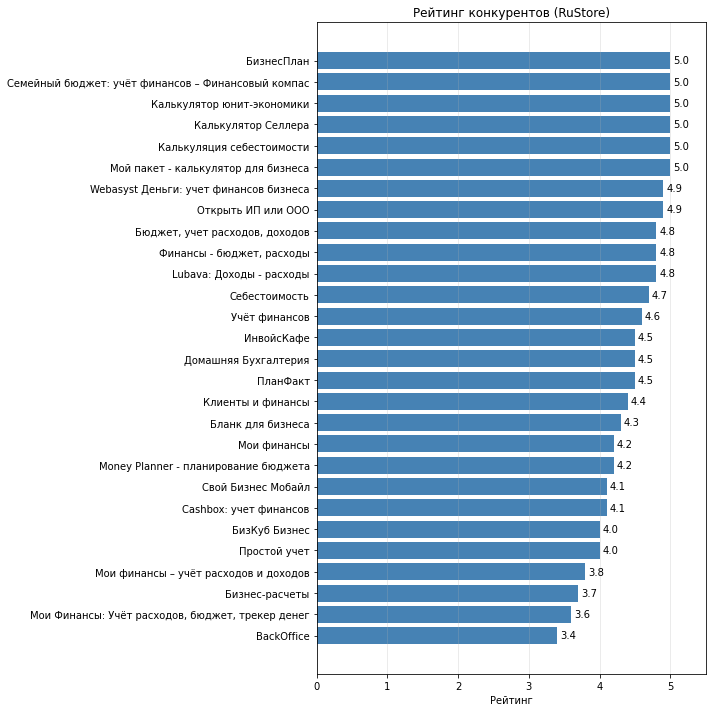

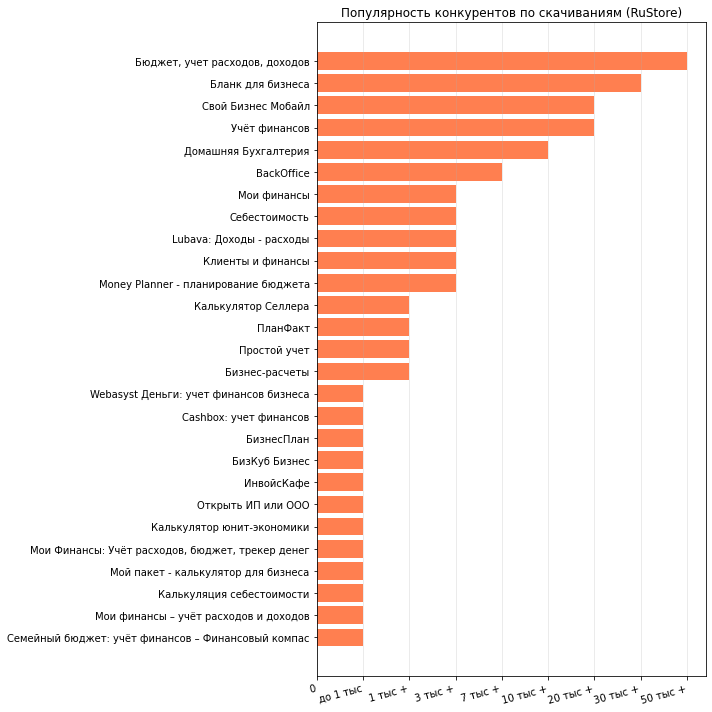

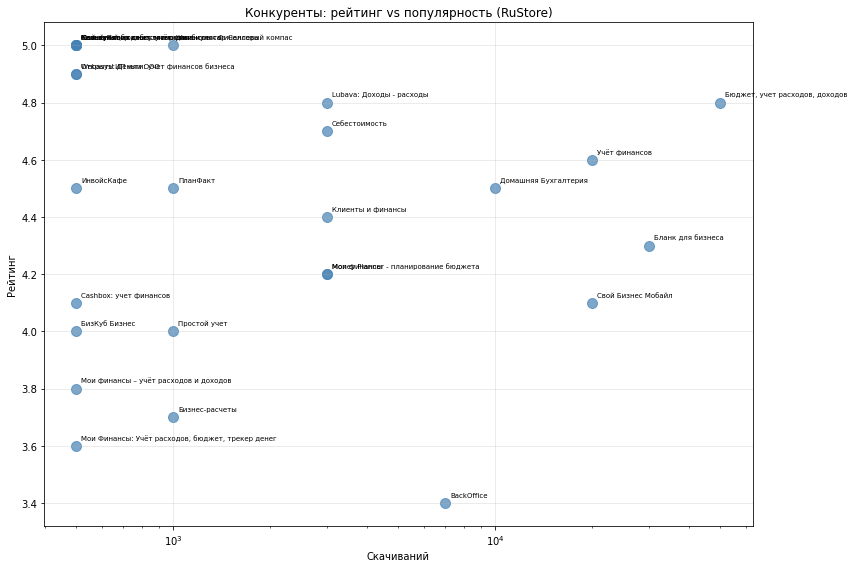

In [4]:
class CompetitorsAnalyzer:
    def __init__(self, df):
        self.df = df[df["рейтинг"] > 0].copy()
        self.download_map = {
            "до 1 тыс": 500, "1 тыс +": 1000, "3 тыс +": 3000,
            "7 тыс +": 7000, "10 тыс +": 10000, "20 тыс +": 20000,
            "30 тыс +": 30000, "50 тыс +": 50000
        }
        self.df["скачивания_число"] = self.df["скачивания"].map(self.download_map)

    def plot_rating(self):
        fig, ax = plt.subplots(figsize=(10, 10))
        df_plot = self.df.sort_values("рейтинг", ascending=True)
        bars = ax.barh(df_plot["название"], df_plot["рейтинг"], color="steelblue")
        ax.set_title("Рейтинг конкурентов (RuStore)")
        ax.set_xlabel("Рейтинг")
        ax.set_xlim(0, 5.5)
        ax.bar_label(ax.containers[0], fmt="%.1f", padding=3)
        ax.grid(True, alpha=0.3, axis="x")
        plt.tight_layout()
        plt.show()

    def plot_downloads(self):
        download_order = ["0", "до 1 тыс", "1 тыс +", "3 тыс +", "7 тыс +",
                          "10 тыс +", "20 тыс +", "30 тыс +", "50 тыс +"]
        df_plot = self.df[self.df["скачивания"].isin(download_order)].copy()
        df_plot["скачивания_порядок"] = df_plot["скачивания"].apply(lambda x: download_order.index(x))
        df_plot = df_plot.sort_values("скачивания_порядок", ascending=True)
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.barh(df_plot["название"], df_plot["скачивания_порядок"], color="coral")
        ax.set_xticks(range(len(download_order)))
        ax.set_xticklabels(download_order, rotation=15, ha="right")
        ax.set_title("Популярность конкурентов по скачиваниям (RuStore)")
        ax.grid(True, alpha=0.3, axis="x")
        plt.tight_layout()
        plt.show()

    def plot_scatter(self):
        df_plot = self.df.dropna(subset=["скачивания_число"])
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.scatter(df_plot["скачивания_число"], df_plot["рейтинг"],
                   color="steelblue", s=100, alpha=0.7)
        for _, row in df_plot.iterrows():
            ax.annotate(row["название"], (row["скачивания_число"], row["рейтинг"]),
                        fontsize=7, ha="left", va="bottom",
                        xytext=(5, 5), textcoords="offset points")
        ax.set_title("Конкуренты: рейтинг vs популярность (RuStore)")
        ax.set_xlabel("Скачиваний")
        ax.set_ylabel("Рейтинг")
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

competitors_analyzer = CompetitorsAnalyzer(df_competitors)
competitors_analyzer.plot_rating()
competitors_analyzer.plot_downloads()
competitors_analyzer.plot_scatter()

### Дашборд

In [ ]:
class CompetitorsDashboard:
    def __init__(self, df):
        self.df = df[df["рейтинг"] > 0].copy()
        self.download_map = {
            "до 1 тыс": 500, "1 тыс +": 1000, "3 тыс +": 3000,
            "7 тыс +": 7000, "10 тыс +": 10000, "20 тыс +": 20000,
            "30 тыс +": 30000, "50 тыс +": 50000
        }
        self.df["скачивания_число"] = self.df["скачивания"].map(self.download_map)
        self.app = Dash(__name__)
        self.setup_layout()

    def setup_layout(self):
        df = self.df

        fig_rating = px.bar(
            df.sort_values("рейтинг", ascending=True),
            x="рейтинг", y="название", orientation="h",
            title="Рейтинг конкурентов (RuStore)",
            labels={"рейтинг": "Рейтинг", "название": ""}
        )

        download_order = ["0", "до 1 тыс", "1 тыс +", "3 тыс +", "7 тыс +",
                          "10 тыс +", "20 тыс +", "30 тыс +", "50 тыс +"]
        df_dl = df[df["скачивания"].isin(download_order)].copy()
        df_dl["скачивания_порядок"] = df_dl["скачивания"].apply(lambda x: download_order.index(x))
        df_dl = df_dl.sort_values("скачивания_порядок", ascending=True)
        fig_downloads = px.bar(
            df_dl, x="скачивания_порядок", y="название", orientation="h",
            title="Популярность конкурентов по скачиваниям (RuStore)",
            labels={"скачивания_порядок": "Скачивания", "название": ""}
        )
        fig_downloads.update_layout(
            xaxis=dict(tickvals=list(range(len(download_order))),
                       ticktext=download_order)
        )

        fig_scatter = px.scatter(
            df.dropna(subset=["скачивания_число"]),
            x="скачивания_число", y="рейтинг",
            hover_name="название",
            title="Конкуренты: рейтинг vs популярность",
            labels={"скачивания_число": "Скачиваний", "рейтинг": "Рейтинг"},
            log_x=True
        )

        self.app.layout = html.Div([
            html.H1("Анализ конкурентов — RuStore",
                    style={"textAlign": "center", "fontFamily": "Arial"}),
            dcc.Graph(figure=fig_rating),
            dcc.Graph(figure=fig_downloads),
            dcc.Graph(figure=fig_scatter),
        ])

    def run(self):
        self.app.run(debug=False, port=8051)

dashboard_competitors = CompetitorsDashboard(df_competitors)
dashboard_competitors.run()

Dash is running on http://127.0.0.1:8051/

 * Serving Flask app "__main__" (lazy loading)
 * Environment: production
   Use a production WSGI server instead.
 * Debug mode: off


 * Running on http://127.0.0.1:8051/ (Press CTRL+C to quit)
